# Z4 domain-wall junction run --- string + velocity diagnostics

Four runs from `scan_z4_junction/`: model in {physical, PRS} x beta_4 in {0.05, 0.10}
(no seed-averaging --- single seed per cell). New file `average_wall_diagnostics.txt`
(infrequent schedule, eta=0,5,10,...) carries the theta-winding junction-string
diagnostics and the selector-A/selector-B wall-velocity sums introduced for this run.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rc

# Set True for the paper LaTeX style (requires a local LaTeX install); False lets this
# notebook execute anywhere (e.g. CI / headless nodes without latex).
USETEX = True
rc('text', usetex=USETEX)
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica'],
              'weight': 'bold', 'size': 16})

## Configuration

In [2]:
BASE = '/mt/user-batch/dpasari/scan_z4_junction/'

# Couplings shared between models at fixed beta_4
LAMBDA = {
    0.05: {'lambda1': 1.0526315789, 'lambda2': 0.0263157895},
    0.10: {'lambda1': 1.1111111111, 'lambda2': 0.0555555556},
}

RUNS = {
    'phys_b005': {'model': 'physical', 'beta': 0.05, 'mu': 0.07, 'H0': 0.07,
                  'L': 143.11, 'N': 512, 'dirname': 'results_phys_b40p05_s01'},
    'phys_b010': {'model': 'physical', 'beta': 0.10, 'mu': 0.07, 'H0': 0.07,
                  'L': 143.11, 'N': 512, 'dirname': 'results_phys_b40p1_s01'},
    'prs_b005':  {'model': 'PRS',      'beta': 0.05, 'mu': 1.0,  'H0': 1.0,
                  'L': 279.0,  'N': 512, 'dirname': 'results_prs_b40p05_s01'},
    'prs_b010':  {'model': 'PRS',      'beta': 0.10, 'mu': 1.0,  'H0': 1.0,
                  'L': 279.0,  'N': 512, 'dirname': 'results_prs_b40p1_s01'},
}

for rid, r in RUNS.items():
    r['lambda1'] = LAMBDA[r['beta']]['lambda1']
    r['lambda2'] = LAMBDA[r['beta']]['lambda2']
    r['DX'] = r['L'] / r['N']
    r['path'] = os.path.join(BASE, r['dirname'])

# COLOR encodes beta_4, LINESTYLE encodes model
_CMAP = plt.cm.winter
COLOR = {0.05: _CMAP(0.15), 0.10: _CMAP(0.85)}
LINESTYLE = {'physical': '-', 'PRS': '--'}
LW = 2.4

# Wall-formation cutoff: eta < ETA_FORM is the pre-formation field-rolling /
# network-formation transient (walls have formed by eta~10 physical, eta~6 PRS), so the
# velocity diagnostics there reflect the random IC, not the wall network. Cut it from the
# velocity plots (sections 7,8) and from the summary-table velocity averages (section 10).
ETA_FORM = 15.0

def style_of(rid):
    r = RUNS[rid]
    return COLOR[r['beta']], LINESTYLE[r['model']]

def make_legend(ax, **kw):
    # Two handle groups: (a) beta color, (b) model linestyle (black)
    beta_handles = [Line2D([0], [0], color=COLOR[b], lw=LW, ls='-',
                            label=rf'$\beta_4={b:.2f}$') for b in (0.05, 0.10)]
    model_handles = [Line2D([0], [0], color='k', lw=LW, ls=LINESTYLE[m], label=m)
                      for m in ('physical', 'PRS')]
    kw.setdefault('fontsize', 13)
    kw.setdefault('frameon', False)
    kw.setdefault('loc', 'upper left')
    kw.setdefault('bbox_to_anchor', (1.02, 1.0))
    kw.setdefault('borderaxespad', 0)
    ax.legend(handles=beta_handles + model_handles, **kw)

# Sizing sanity table: junction-core resolution at a=1
print(f"{'id':>10s} {'model':>9s} {'beta':>5s} {'mu':>5s} {'L':>7s} {'DX':>7s} "
      f"{'cells/core@a=1':>15s}")
print('-' * 64)
for rid, r in RUNS.items():
    cells_a1 = 1.0 / (np.sqrt(2.0) * r['mu'] * 1.0 * r['DX'])
    print(f"{rid:>10s} {r['model']:>9s} {r['beta']:>5.2f} {r['mu']:>5.2f} "
          f"{r['L']:>7.2f} {r['DX']:>7.4f} {cells_a1:>15.2f}")

        id     model  beta    mu       L      DX  cells/core@a=1
----------------------------------------------------------------
 phys_b005  physical  0.05  0.07  143.11  0.2795           36.14
 phys_b010  physical  0.10  0.07  143.11  0.2795           36.14
  prs_b005       PRS  0.05  1.00  279.00  0.5449            1.30
  prs_b010       PRS  0.10  1.00  279.00  0.5449            1.30


## Loaders

`average_energies.txt`, `average_scale_factor.txt`, `average_scalar_{0,1}.txt` are on the
regular fine output schedule; `average_wall_diagnostics.txt` (the new file) is on the
infrequent schedule (eta = 0, 5, 10, ...). All files are whitespace-column text with no
header line (`print_headers=false`).

In [3]:
def _safe_loadtxt(fpath):
    try:
        if not os.path.exists(fpath) or os.path.getsize(fpath) == 0:
            return None
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError, ValueError, StopIteration):
        return None
    if data.size == 0:
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    return data


def load_energies(path):
    # 11 cols: eta,Ek1,Ek2,Eg1,Eg2,Ev1,Ev2,Ev3,Etot,scal1(adj),scal2(opp)
    data = _safe_loadtxt(os.path.join(path, 'average_energies.txt'))
    if data is None or data.shape[1] < 11:
        return None
    return {
        'eta': data[:, 0], 'Ek_1': data[:, 1], 'Ek_2': data[:, 2],
        'Eg_1': data[:, 3], 'Eg_2': data[:, 4], 'Ev_1': data[:, 5],
        'Ev_2': data[:, 6], 'Ev_3': data[:, 7], 'E_tot': data[:, 8],
        'scal1': data[:, 9], 'scal2': data[:, 10],
    }


def load_scale_factor(path):
    # 4 cols: eta, a, a', H -- use a=col1, H=col3 (NOT a'=col2)
    data = _safe_loadtxt(os.path.join(path, 'average_scale_factor.txt'))
    if data is None or data.shape[1] < 4:
        return None
    return {'eta': data[:, 0], 'a': data[:, 1], 'aprime': data[:, 2], 'H': data[:, 3]}


def load_scalar(path, idx):
    # >=6 cols: eta, phi, phi_prime, phi2, phi_prime2, rms_phi [, extra col ignored]
    data = _safe_loadtxt(os.path.join(path, f'average_scalar_{idx}.txt'))
    if data is None or data.shape[1] < 6:
        return None
    return {
        'eta': data[:, 0], 'phi': data[:, 1], 'phi_prime': data[:, 2],
        'phi2': data[:, 3], 'phi_prime2': data[:, 4], 'rms_phi': data[:, 5],
    }


_WALLDIAG_COLS = [
    'eta',
    'Jstr_len', 'Jstr_cnt', 'Jstr_signed', 'Jstr_w2', 'Jpi_edge', 'Jcore_cnt',
    'velA02_KE', 'velA02_V', 'velA02_N',
    'velA04_KE', 'velA04_V', 'velA04_N',
    'velA06_KE', 'velA06_V', 'velA06_N',
    'velBadj_KE', 'velBadj_V', 'velBadj_N',
    'velBnon_KE', 'velBnon_V', 'velBnon_N',
    'velBall_KE', 'velBall_V', 'velBall_N',
]

def load_wall_diag(path):
    # 25 cols, infrequent schedule (eta=0,5,10,...)
    data = _safe_loadtxt(os.path.join(path, 'average_wall_diagnostics.txt'))
    if data is None or data.shape[1] < 25:
        return None
    return {name: data[:, i] for i, name in enumerate(_WALLDIAG_COLS)}


def load_run(rid):
    r = RUNS[rid]
    path = r['path']
    en = load_energies(path)
    sf = load_scale_factor(path)
    s0 = load_scalar(path, 0)
    s1 = load_scalar(path, 1)
    wd = load_wall_diag(path)
    if any(x is None for x in [en, sf, s0, s1, wd]):
        return None
    return {'energies': en, 'scale_factor': sf, 'scalar_0': s0, 'scalar_1': s1,
            'wall_diag': wd, 'model': r['model']}


RUNS_DATA = {}
print(f"{'id':>10s} {'loaded':>7s} {'last_eta(energies)':>19s} {'last_eta(walldiag)':>19s} "
      f"{'n_walldiag_rows':>15s}")
print('-' * 78)
for rid in RUNS:
    d = load_run(rid)
    RUNS_DATA[rid] = d
    if d is None:
        print(f"{rid:>10s} {'NO':>7s}")
        continue
    le = d['energies']['eta'][-1]
    lw = d['wall_diag']['eta'][-1]
    nw = len(d['wall_diag']['eta'])
    print(f"{rid:>10s} {'yes':>7s} {le:>19.2f} {lw:>19.2f} {nw:>15d}")

        id  loaded  last_eta(energies)  last_eta(walldiag) n_walldiag_rows
------------------------------------------------------------------------------
 phys_b005     yes               70.49               69.65              15
 phys_b010     yes               70.49               69.65              15
  prs_b005     yes               99.94               99.84              21
  prs_b010     yes               99.94               99.84              21


## Plot helpers

In [4]:
def paper_ax(ax, xlabel=r'$\eta$', ylabel='', title=''):
    ax.set_xlabel(xlabel, fontsize=24)
    if ylabel: ax.set_ylabel(ylabel, fontsize=24)
    if title:  ax.set_title(title,   fontsize=20)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', which='both', direction='in', labelsize=18, pad=6)
    ax.tick_params(which='major', length=9)
    ax.tick_params(which='minor', length=4)
    ax.minorticks_on()
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)


def phi2_radial(run):
    # <|Phi|^2> = (phi2 of field 0 + phi2 of field 1) / 2
    s0, s1 = run['scalar_0'], run['scalar_1']
    n = min(len(s0['eta']), len(s1['eta']))
    return s0['eta'][:n], (s0['phi2'][:n] + s1['phi2'][:n]) / 2.0


def area_param(en_key, run):
    # A = scal / (2 a H) vs eta; a,H interpolated from the scale-factor file
    en, sf = run['energies'], run['scale_factor']
    a_arr = np.interp(en['eta'], sf['eta'], sf['a'])
    H_arr = np.interp(en['eta'], sf['eta'], sf['H'])
    with np.errstate(divide='ignore', invalid='ignore'):
        A = en[en_key] / (2.0 * a_arr * H_arr)
    return en['eta'], A


def a_of_walldiag_eta(run):
    # a(eta) on the wall_diag eta grid, interpolated from scale_factor
    wd, sf = run['wall_diag'], run['scale_factor']
    return np.interp(wd['eta'], sf['eta'], sf['a'])


def cells_per_core(rid, run):
    # core half-width = 1/(sqrt(2) mu). PHYSICAL walls/cores thin comoving as 1/a, so
    # cells_per_core(a) = 1/(sqrt(2) mu a DX). PRS FREEZES the comoving width: the same
    # a^(3+alpha)->a^(1+alpha) potential-freezing that fixes the wall number also fixes the
    # core, so cells/core is CONSTANT at the a=1 value (a_eff=1, as in Z2 cells_per_wall_seed).
    # Confirmed by the measured Jcore_cnt persisting (no collapse) and <|Phi|^2> staying at
    # vacuum the whole PRS run.  (a_arr returned is the REAL a, for the x-axis / a_resolved.)
    mu, DX = RUNS[rid]['mu'], RUNS[rid]['DX']
    a_arr = a_of_walldiag_eta(run)
    a_eff = np.ones_like(a_arr) if RUNS[rid]['model'] == 'PRS' else a_arr
    with np.errstate(divide='ignore', invalid='ignore'):
        cpc = 1.0 / (np.sqrt(2.0) * mu * a_eff * DX)
    return a_arr, cpc


def junction_scaling(run):
    # Junction = codim-2 string => length density L/V ~ H^2 (TWO horizon powers), vs the
    # wall's area density A/V ~ H (one power). Scaling parameter (same a-power as the wall
    # but with H^2 instead of H):  xi = Jstr_len / (2 a H^2).
    # a, H interpolated from average_scale_factor.txt onto the wall_diag eta grid.
    wd, sf = run['wall_diag'], run['scale_factor']
    eta = wd['eta']
    a_arr = np.interp(eta, sf['eta'], sf['a'])
    H_arr = np.interp(eta, sf['eta'], sf['H'])
    with np.errstate(divide='ignore', invalid='ignore'):
        xi = wd['Jstr_len'] / (2.0 * a_arr * H_arr**2)
    xi = np.asarray(xi, dtype=float)
    bad = ~np.isfinite(xi) | (xi <= 0)
    xi = xi.copy()
    xi[bad] = np.nan
    return eta, xi


def safe_ratio(num, den):
    # elementwise num/den with non-finite / den<=0 masked to NaN
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        r = num / den
    bad = ~np.isfinite(r) | (den <= 0)
    r = r.copy()
    r[bad] = np.nan
    return r


def v2gamma2(run, sel):
    # v^2 gamma^2 = KE/V over wall sites for a selector prefix, e.g. 'velBadj'.
    # The C++ KE term is the PHYSICAL-time density 0.5 a^-6 pi^2 (energies.h convention).
    # In the PRS run the wall term in the EOM is a^(1+alpha), not a^(3+alpha)
    # (scalarsingletkernels.h:60): the wall equilibrates against the EFFECTIVE potential
    # V_eff = a^-2 V.  Equivalently the PRS estimator should use the CONFORMAL-time kinetic
    # term <(dphi/deta)^2>/<2V> (PRS papers), which restores one factor of a^2.
    # => PRS gets a per-eta x a(eta)^2; the physical formula is unchanged.
    wd = run['wall_diag']
    vg = safe_ratio(wd[f'{sel}_KE'], wd[f'{sel}_V'])
    if run.get('model') == 'PRS':
        vg = vg * a_of_walldiag_eta(run)**2
    return wd['eta'], vg


def v2_from_v2gamma2(x):
    # RMS 3-velocity^2: v^2 = x/(1+x)
    x = np.asarray(x, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        v2 = x / (1.0 + x)
    return v2


def phys_core_resolved_eta_hi():
    # eta at which a physical run's cells_per_core drops below 1, i.e. where its scale
    # factor a crosses a_max = 1/(sqrt(2) mu dx) ~ 36. Used to shade the trustworthy
    # window in section 3b. Returns None if no physical run is loaded.
    for rid, run in RUNS_DATA.items():
        if run is None or RUNS[rid]['model'] != 'physical':
            continue
        mu, DX = RUNS[rid]['mu'], RUNS[rid]['DX']
        a_max = 1.0 / (np.sqrt(2.0) * mu * DX)
        sf = run['scale_factor']
        return float(np.interp(a_max, sf['a'], sf['eta']))
    return None

# Part I --- Headline physics

The runs sit at $\beta_4=0.05,0.10$, both **below** the $\beta_4=1/3$ threshold at which
opposite ($\Delta\theta=\pi$) walls are bound. Below it the opposite walls do not survive
and the "non-adjacent" selector mask instead counts antipodal under-resolution edges (see
Part II, §A1). So the headline physics is the **adjacent** wall + **junction** network:
their scaling parameters, the junction-string length, and the adjacent/all wall velocity.

## 1. Health & cosmology

Left: radial diagnostic $\langle|\Phi|^2\rangle$ (vacuum $=0.5$, broken $\approx0.43$--$0.47$).
Right: scale factor $a(\eta)$. Four curves: color = $\beta_4$, linestyle = model.

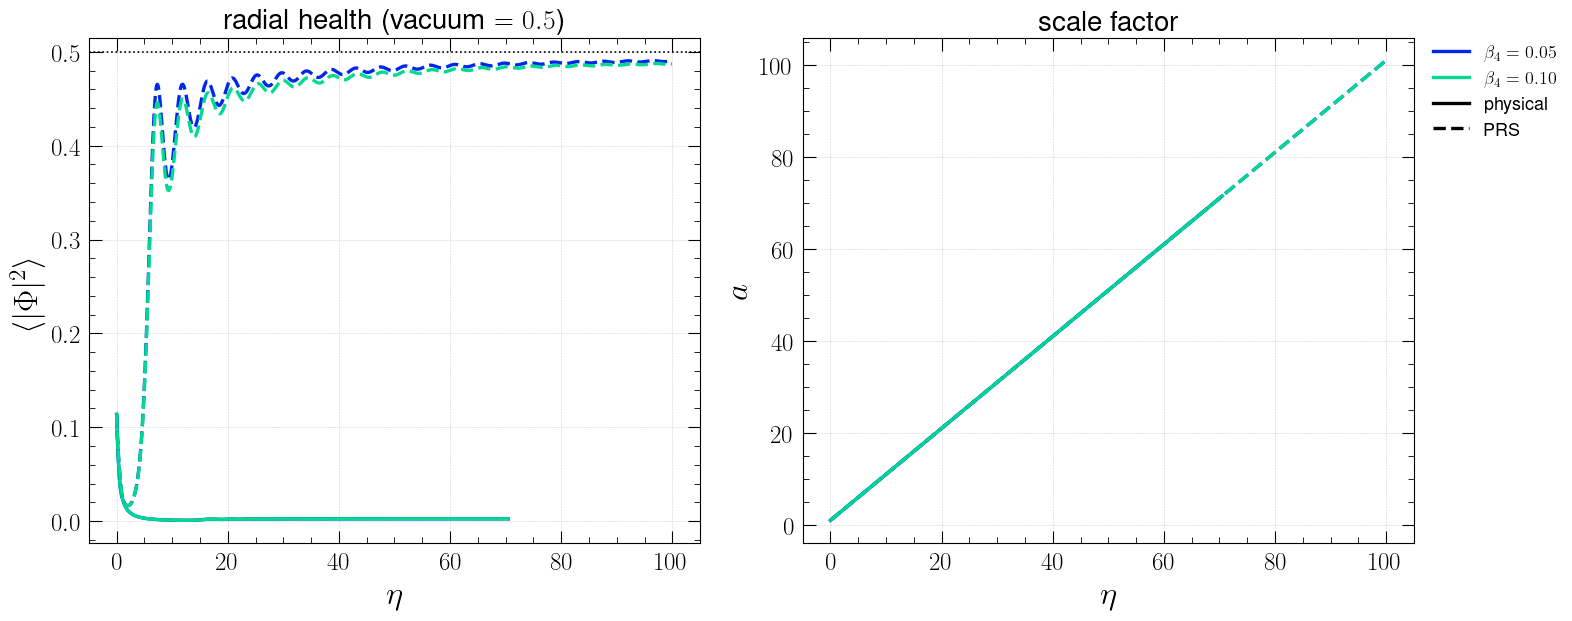

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for rid, run in RUNS_DATA.items():
    if run is None:
        continue
    color, ls = style_of(rid)
    eta, p2 = phi2_radial(run)
    axes[0].plot(eta, p2, color=color, ls=ls, lw=LW)
    sf = run['scale_factor']
    axes[1].plot(sf['eta'], sf['a'], color=color, ls=ls, lw=LW)

axes[0].axhline(0.5, color='k', ls=':', lw=1.2)
paper_ax(axes[0], ylabel=r'$\langle|\Phi|^2\rangle$', title=r'radial health (vacuum $=0.5$)')
paper_ax(axes[1], ylabel=r'$a$', title=r'scale factor')
make_legend(axes[1])
plt.tight_layout(); plt.show()

## 2. Adjacent-wall scaling $\mathcal{A}_1 = \mathrm{scal}_1/(2aH)$

A wall is a codim-1 surface, so its comoving area density scales as $A/V\propto H$ (one
horizon power): $\mathcal{A}_1\equiv\mathrm{scal}_1/(2aH)$. Left: $\mathcal{A}_1$ vs
$\eta$. Right: the local log-slope ${\rm d}\ln\mathcal{A}_1/{\rm d}\ln\eta$ (pointwise
`np.gradient` on log--log, as in §3b); flat $\Rightarrow$ scaling, with a residual
$\approx-0.84$ from the radiation background. (The opposite-wall $\mathcal{A}_2$ is moved
to Part II §A1, where it is shown not to be a surviving wall at $\beta_4<1/3$.)

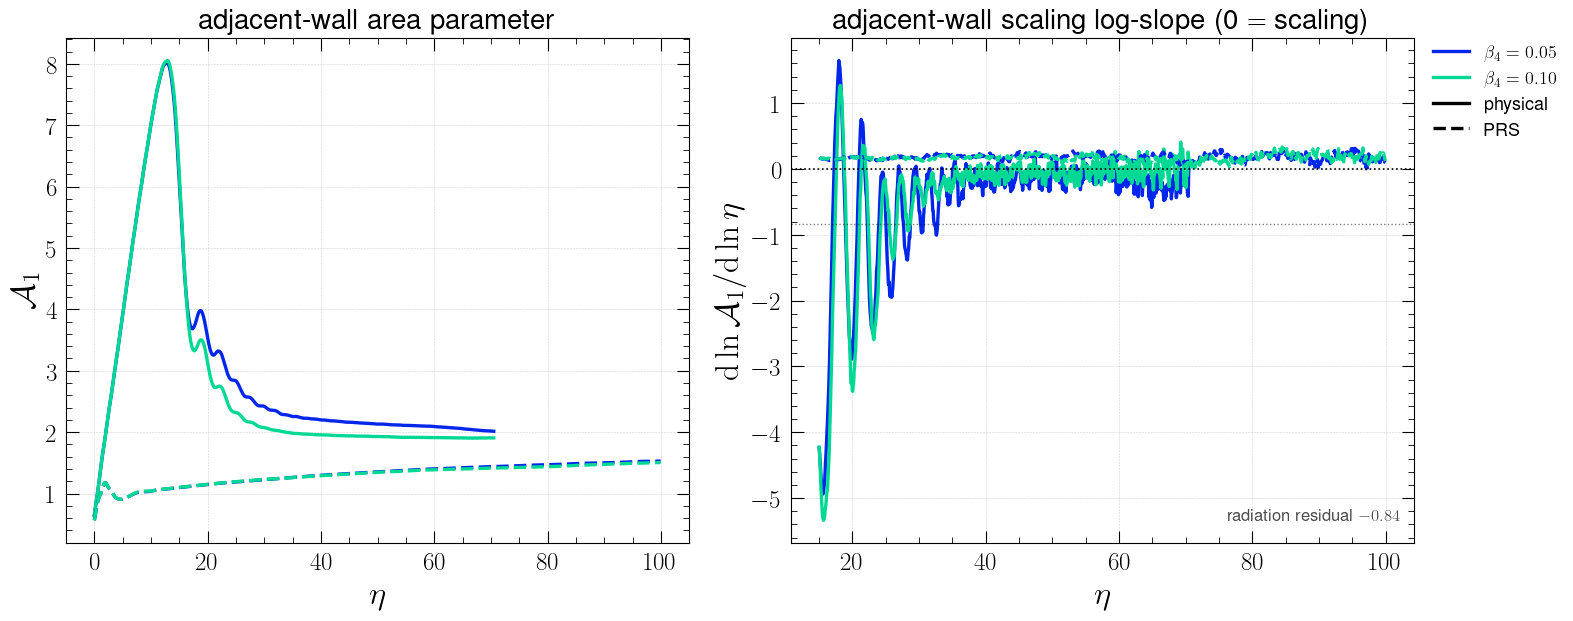

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for rid, run in RUNS_DATA.items():
    if run is None:
        continue
    color, ls = style_of(rid)
    eta1, A1 = area_param('scal1', run)
    axes[0].plot(eta1, A1, color=color, ls=ls, lw=LW)

    # local log-slope dln A1/dln eta, pointwise np.gradient on log-log (same approach as
    # section 3b's slope panel); restrict to positive-finite points post-formation.
    pos = (eta1 >= ETA_FORM) & np.isfinite(A1) & (A1 > 0) & (eta1 > 0)
    if pos.sum() >= 2:
        lx = np.log(eta1[pos]); ly = np.log(A1[pos])
        axes[1].plot(eta1[pos], np.gradient(ly, lx), color=color, ls=ls, lw=LW)

axes[1].axhline(0.0, color='k', ls=':', lw=1.2)
axes[1].axhline(-0.84, color='k', ls=':', lw=1.0, alpha=0.5)
axes[1].text(0.98, 0.04, r'radiation residual $-0.84$', transform=axes[1].transAxes,
             ha='right', va='bottom', fontsize=12, color='k', alpha=0.7)
paper_ax(axes[0], ylabel=r'$\mathcal{A}_1$', title=r'adjacent-wall area parameter')
paper_ax(axes[1], ylabel=r'${\rm d}\ln\mathcal{A}_1/{\rm d}\ln\eta$',
         title=r'adjacent-wall scaling log-slope (0 $=$ scaling)')
make_legend(axes[1])
plt.tight_layout(); plt.show()

## 3. Junction-string length

Left: comoving length density of $|{\rm winding}|\ge1$ faces, `Jstr_len`. Right: raw
pierced-face count `Jstr_cnt` (log $y$ --- the $\eta=0$ random-IC point is enormous
since the network has not formed yet; it forms around $a\sim20$).

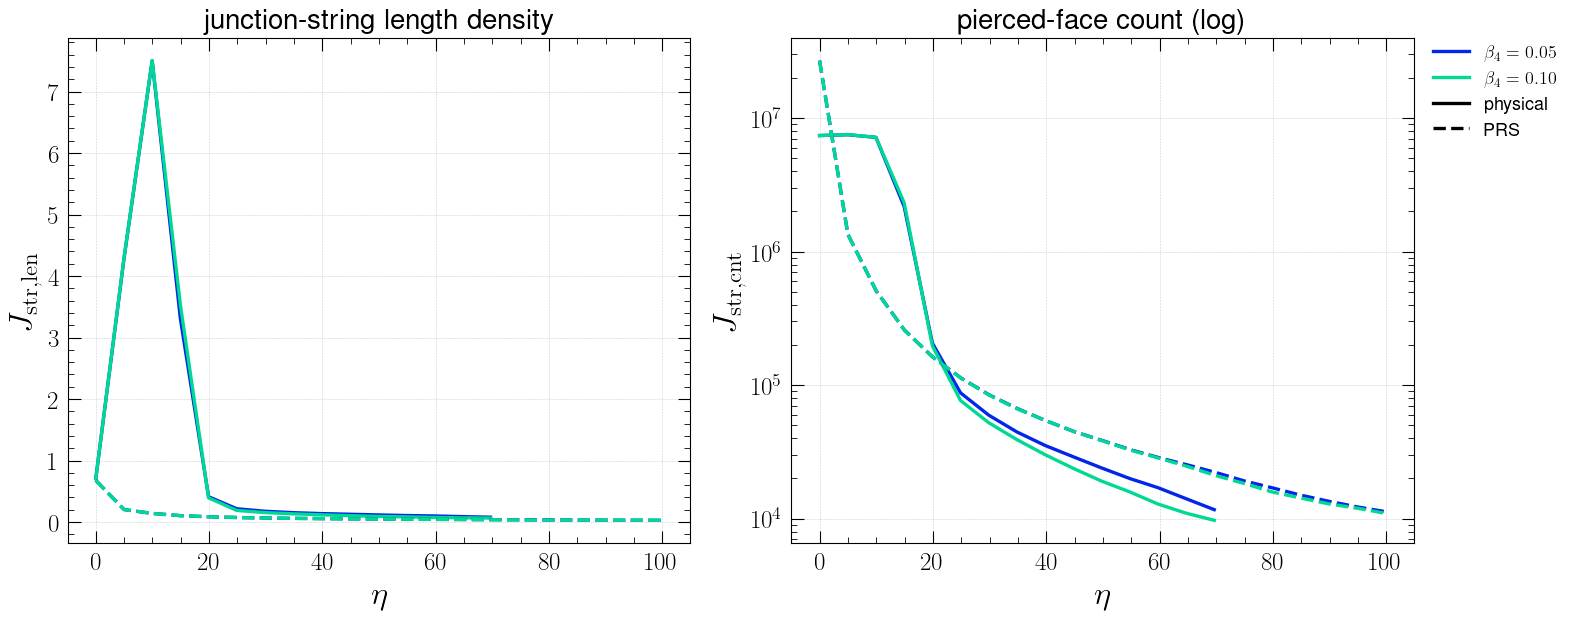

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for rid, run in RUNS_DATA.items():
    if run is None:
        continue
    color, ls = style_of(rid)
    wd = run['wall_diag']
    axes[0].plot(wd['eta'], wd['Jstr_len'], color=color, ls=ls, lw=LW)
    axes[1].plot(wd['eta'], wd['Jstr_cnt'], color=color, ls=ls, lw=LW)

axes[1].set_yscale('log')
paper_ax(axes[0], ylabel=r'$J_{\rm str,len}$', title=r'junction-string length density')
paper_ax(axes[1], ylabel=r'$J_{\rm str,cnt}$', title=r'pierced-face count (log)')
make_legend(axes[1])
plt.tight_layout(); plt.show()

## 3b. Junction scaling parameter $\xi = J_{\rm str,len}/(2aH^2)$

A junction is a codim-2 string, so its comoving length density scales as $L/V\propto H^2$
(**two** horizon powers), unlike a wall's area density $A/V\propto H$ (one power). The
junction scaling parameter uses the same $a$-power as the wall area but $H^2$ instead of
$H$:
$$\xi \equiv \frac{J_{\rm str,len}}{2aH^2}.$$
If $\xi$ is flat in $\eta$ the junction network scales. Empirically $\xi$ flattens the raw
$J_{\rm str,len}$ log-slope from $\approx-1.8$ to a residual $\approx-0.8$, which **matches
the wall parameter's own $-0.84$ residual** --- i.e. the leftover slope is the radiation
background, not a units artifact. The physical runs are junction-core-resolved only for
$a\lesssim36$ (shaded), then thin below the grid; the **PRS** core is *frozen* at
$\approx1.3$ cells (half-width, $\approx2.6$ full) and stays marginally resolved the whole
run (§A5), so its $\xi$ is shown across the full range but at borderline resolution.

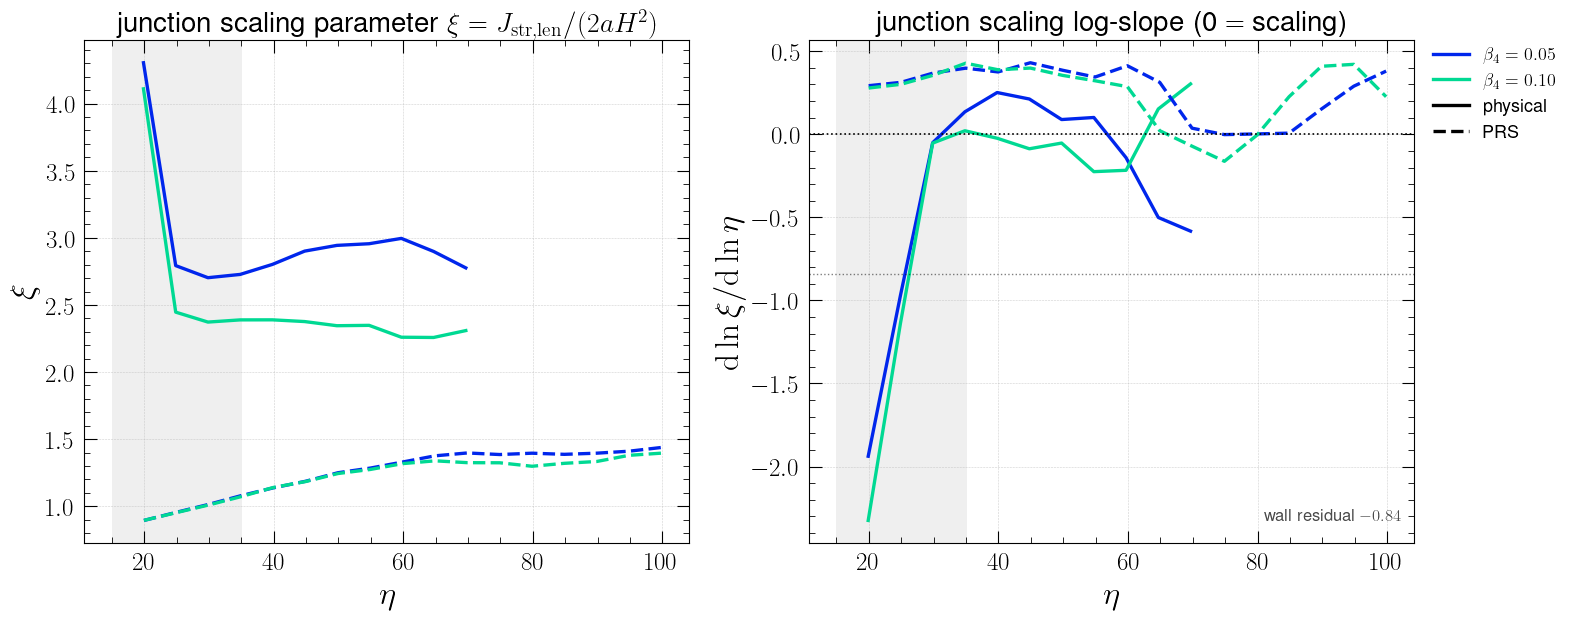

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# physical core-resolved upper eta (cells_per_core drops below 1 where a crosses ~36)
eta_hi_res = phys_core_resolved_eta_hi()

for rid, run in RUNS_DATA.items():
    if run is None:
        continue
    color, ls = style_of(rid)
    eta, xi = junction_scaling(run)

    # LEFT: xi vs eta, post-formation only (drop eta < ETA_FORM IC garbage)
    m = (eta >= ETA_FORM) & np.isfinite(xi)
    axes[0].plot(eta[m], xi[m], color=color, ls=ls, lw=LW)

    # RIGHT: pointwise local log-slope dln(xi)/dln(eta) on the positive-finite points.
    # Only ~12-18 points per run, so a simple np.gradient on log-log is used (NOT the
    # 60-bin local_logslope, which needs far more samples).
    pos = m & (eta > 0)
    if pos.sum() >= 2:
        lx = np.log(eta[pos]); ly = np.log(xi[pos])
        slope = np.gradient(ly, lx)
        axes[1].plot(eta[pos], slope, color=color, ls=ls, lw=LW)

# Shade the physical core-resolved post-formation window [ETA_FORM, eta_hi_res]
if eta_hi_res is not None and eta_hi_res > ETA_FORM:
    for ax in axes:
        ax.axvspan(ETA_FORM, eta_hi_res, color='grey', alpha=0.12, lw=0)

# slope guides: 0 = scaling target; -0.84 = wall-parameter residual (labelled inline so
# make_legend stays the sole beta/model legend, matching the rest of the notebook)
axes[1].axhline(0.0, color='k', ls=':', lw=1.2)
axes[1].axhline(-0.84, color='k', ls=':', lw=1.0, alpha=0.5)
axes[1].text(0.98, 0.04, r'wall residual $-0.84$', transform=axes[1].transAxes,
             ha='right', va='bottom', fontsize=12, color='k', alpha=0.7)

paper_ax(axes[0], ylabel=r'$\xi$', title=r'junction scaling parameter $\xi=J_{\rm str,len}/(2aH^2)$')
paper_ax(axes[1], ylabel=r'${\rm d}\ln\xi/{\rm d}\ln\eta$',
         title=r'junction scaling log-slope (0 $=$ scaling)')
make_legend(axes[1])
plt.tight_layout(); plt.show()

## 4. Adjacent-wall velocity

Bounded RMS 3-velocity$^2$, $v^2=x/(1+x)$ with $x={\rm KE/V}$, post-formation
($\eta\ge$ `ETA_FORM`). Left: adjacent walls (selector B `velBadj`). Right: all walls
(selector B union `velBall`). Both bounded $[0,1]$.

**PRS normalization ($\times a^2$).** The C++ `KE` term is the *physical*-time density
$\tfrac12 a^{-6}\pi^2$, but the PRS EOM uses the wall term $a^{1+\alpha}$ instead of
$a^{3+\alpha}$ (`scalarsingletkernels.h:60`): the wall equilibrates against the
*effective* potential $V_{\rm eff}=a^{-2}V$, i.e. the PRS estimator should use the
conformal-time kinetic term $\langle(\partial_\eta\phi)^2\rangle/\langle2V\rangle$. So the
PRS curves carry a per-$\eta$ factor $a(\eta)^2$ (physical curves unchanged). With this
correction the PRS walls are **not** frozen: they move at $v\approx0.5c$ and stay **flat
(scaling)**, while the physical $v^2$ *declines* ($v\sim0.8c\to0.5c$) --- the decline is
the ${\rm KE/V}$ estimator losing the thinning sub-grid wall, not real deceleration.

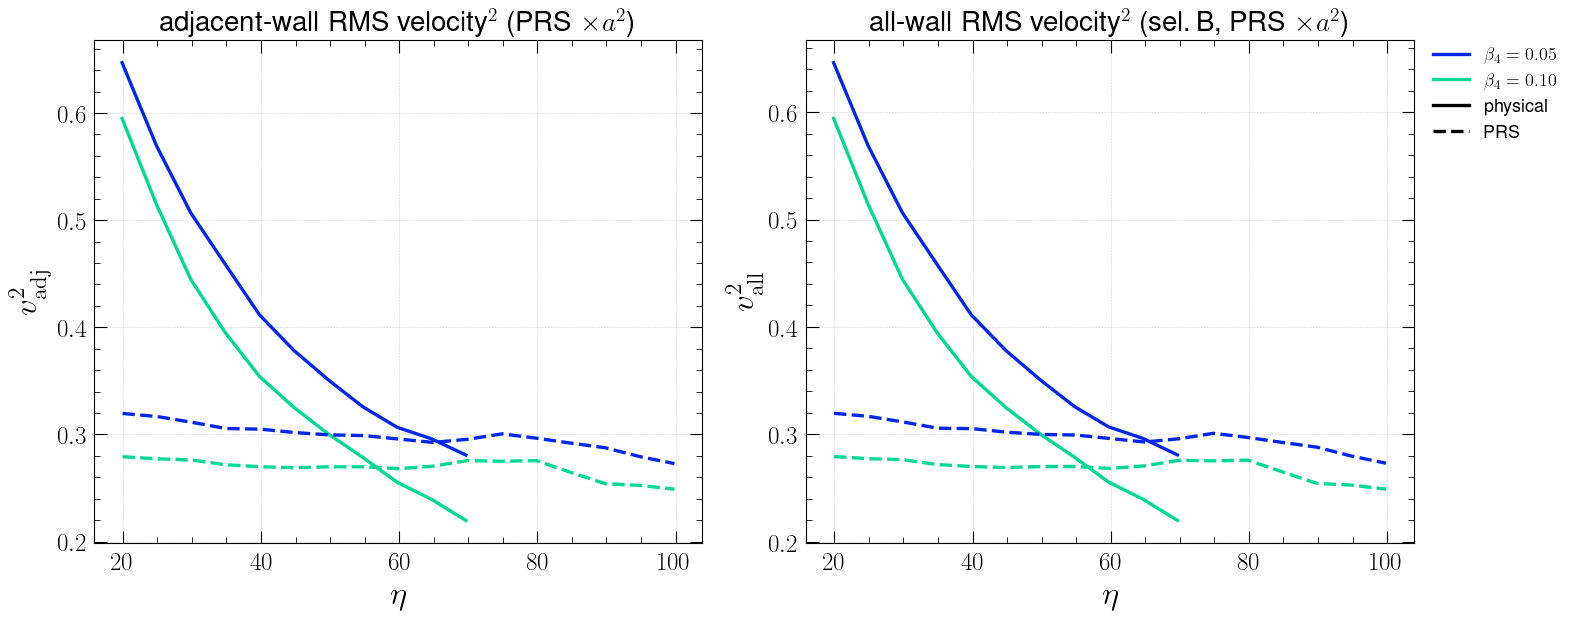

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for rid, run in RUNS_DATA.items():
    if run is None:
        continue
    color, ls = style_of(rid)
    # Left: adjacent-wall v^2; right: all-wall v^2 (selector B union). Drop eta < ETA_FORM.
    eta, vg_adj = v2gamma2(run, 'velBadj')
    v2_adj = v2_from_v2gamma2(vg_adj)
    m = eta >= ETA_FORM
    axes[0].plot(eta[m], v2_adj[m], color=color, ls=ls, lw=LW)
    eta, vg_all = v2gamma2(run, 'velBall')
    v2_all = v2_from_v2gamma2(vg_all)
    m = eta >= ETA_FORM
    axes[1].plot(eta[m], v2_all[m], color=color, ls=ls, lw=LW)

paper_ax(axes[0], ylabel=r'$v^2_{\rm adj}$', title=r'adjacent-wall RMS velocity$^2$ (PRS $\times a^2$)')
paper_ax(axes[1], ylabel=r'$v^2_{\rm all}$', title=r'all-wall RMS velocity$^2$ (sel.\,B, PRS $\times a^2$)')
make_legend(axes[1])
plt.tight_layout(); plt.show()

# Part II --- Validation, resolution & null diagnostics

Everything below is a **check**, not a headline result: it establishes that (i) opposite /
antipodal walls do not survive at $\beta_4<1/3$ and the "non-adjacent" selector is an
under-resolution artifact, (ii) the junction topological charge is conserved, (iii) the
lattice resolution windows, and (iv) the velocity estimator is robust and the kinematic
mask tracks the geometric wall area.

## A1. Opposite / antipodal walls do not survive ($\beta_4<1/3$)

At $\beta_4<1/3$ the opposite ($\Delta\theta=\pi$) walls are unbound and split into pairs
of adjacent walls, so there is no surviving opposite-wall population. **Left:** opposite
abundance --- both $N_{\rm non}/N_{\rm adj}$ (= `velBnon_N/velBadj_N`) and
$\mathrm{scal}_2/\mathrm{scal}_1$ sit at $\sim0.002$--$0.008$ and **fall**. **Right:** the
proof these few sites are artifacts --- $J_{\pi,{\rm edge}}/N_{\rm non}$ (= `Jpi_edge/velBnon_N`)
$\approx1.05$ at all times (guide at $1.0$), i.e. essentially **every** "non-adjacent" site
is an antipodal under-resolution edge, not a wall. Consequence: the §A2-right
"velocity" and $\mathcal{A}_2$ are **not** opposite-wall quantities.

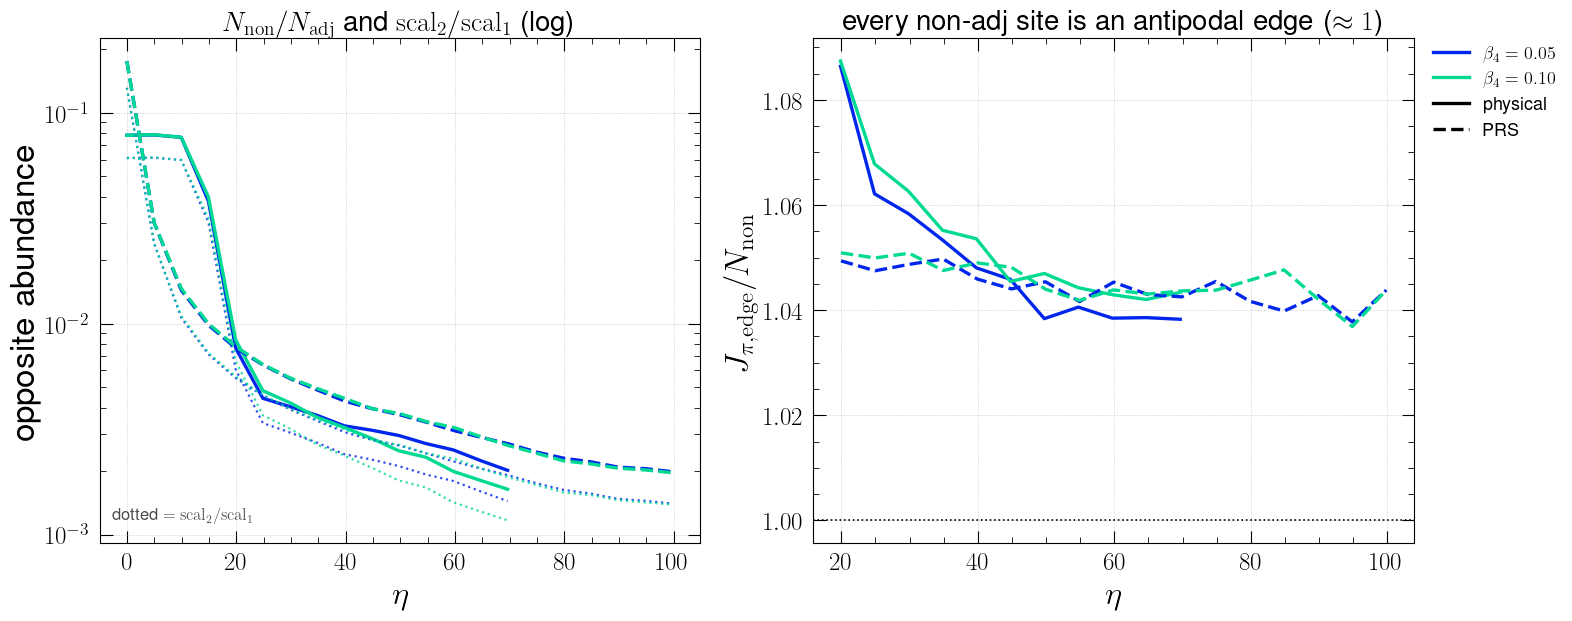

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for rid, run in RUNS_DATA.items():
    if run is None:
        continue
    color, ls = style_of(rid)
    wd = run['wall_diag']
    en = run['energies']
    # Left: opposite abundance. N_non/N_adj (solid-ish, the run linestyle) and
    # scal2/scal1 (same color, dotted overlay) -- both small and falling.
    nn_na = safe_ratio(wd['velBnon_N'], wd['velBadj_N'])
    axes[0].plot(wd['eta'], nn_na, color=color, ls=ls, lw=LW)
    s2_s1 = np.interp(wd['eta'], en['eta'],
                      safe_ratio(en['scal2'], en['scal1']))
    axes[0].plot(wd['eta'], s2_s1, color=color, ls=':', lw=1.6, alpha=0.8)
    # Right: Jpi_edge / N_non -- antipodal-edge fraction of non-adj sites (~1.05).
    jpi_frac = safe_ratio(wd['Jpi_edge'], wd['velBnon_N'])
    m = wd['eta'] >= ETA_FORM
    axes[1].plot(wd['eta'][m], jpi_frac[m], color=color, ls=ls, lw=LW)

axes[0].set_yscale('log')
axes[1].axhline(1.0, color='k', ls=':', lw=1.2)
axes[0].text(0.02, 0.04, r'dotted $=\mathrm{scal}_2/\mathrm{scal}_1$',
             transform=axes[0].transAxes, ha='left', va='bottom', fontsize=12,
             color='k', alpha=0.7)
paper_ax(axes[0], ylabel=r'opposite abundance',
         title=r'$N_{\rm non}/N_{\rm adj}$ and $\mathrm{scal}_2/\mathrm{scal}_1$ (log)')
paper_ax(axes[1], ylabel=r'$J_{\pi,{\rm edge}}/N_{\rm non}$',
         title=r'every non-adj site is an antipodal edge ($\approx1$)')
make_legend(axes[1])
plt.tight_layout(); plt.show()

## A2. Antipodal-flagged-site velocity (under-resolution artifact, NOT opposite walls)

$v^2\gamma^2={\rm KE/V}$ (PRS $\times a^2$, see §4), post-formation, linear $y$.
**Left:** adjacent-wall sites (`velBadj`) --- a genuine wall velocity. **Right:** the
"non-adjacent" selector (`velBnon`). Per §A1 these sites are antipodal **under-resolution
/ junction edges**, not a surviving opposite wall, so the right panel is the velocity of
antipodal-flagged sites and must **not** be read as a physical opposite-wall velocity.

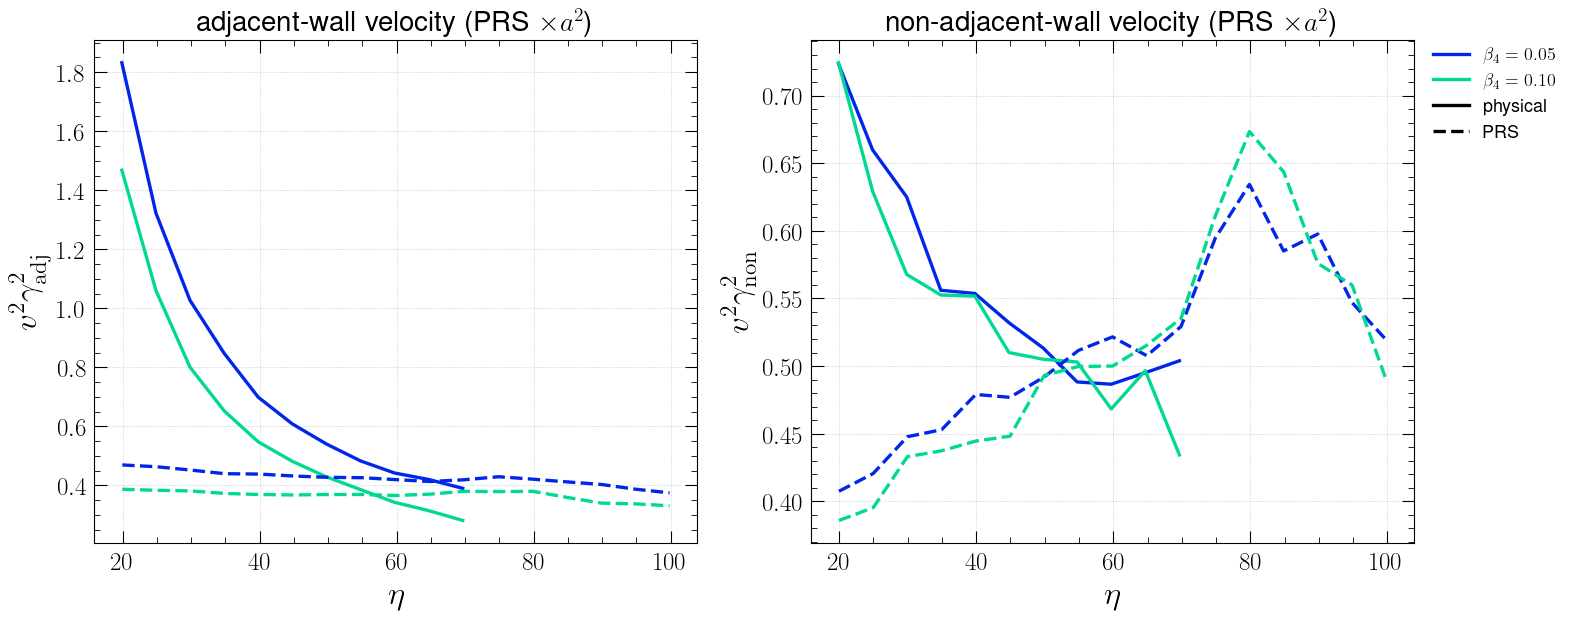

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for rid, run in RUNS_DATA.items():
    if run is None:
        continue
    color, ls = style_of(rid)
    # Drop eta < ETA_FORM entirely (not just set_xlim): removing the pre-formation points
    # lets the linear y-axis autoscale tightly onto the post-formation values.
    eta, vg_adj = v2gamma2(run, 'velBadj')
    m = eta >= ETA_FORM
    axes[0].plot(eta[m], vg_adj[m], color=color, ls=ls, lw=LW)
    eta, vg_non = v2gamma2(run, 'velBnon')
    m = eta >= ETA_FORM
    axes[1].plot(eta[m], vg_non[m], color=color, ls=ls, lw=LW)

paper_ax(axes[0], ylabel=r'$v^2\gamma^2_{\rm adj}$', title=r'adjacent-wall velocity (PRS $\times a^2$)')
paper_ax(axes[1], ylabel=r'$v^2\gamma^2_{\rm non}$', title=r'non-adjacent-wall velocity (PRS $\times a^2$)')
make_legend(axes[1])
plt.tight_layout(); plt.show()

## A3. Junction validation

Left: net-winding fraction `Jstr_signed/Jstr_cnt` --- should stay $\approx0$
(topological-charge sanity check). Right: fraction of $|{\rm winding}|\ge2$ faces
`Jstr_w2/Jstr_cnt` (antipodal under-resolution indicator).

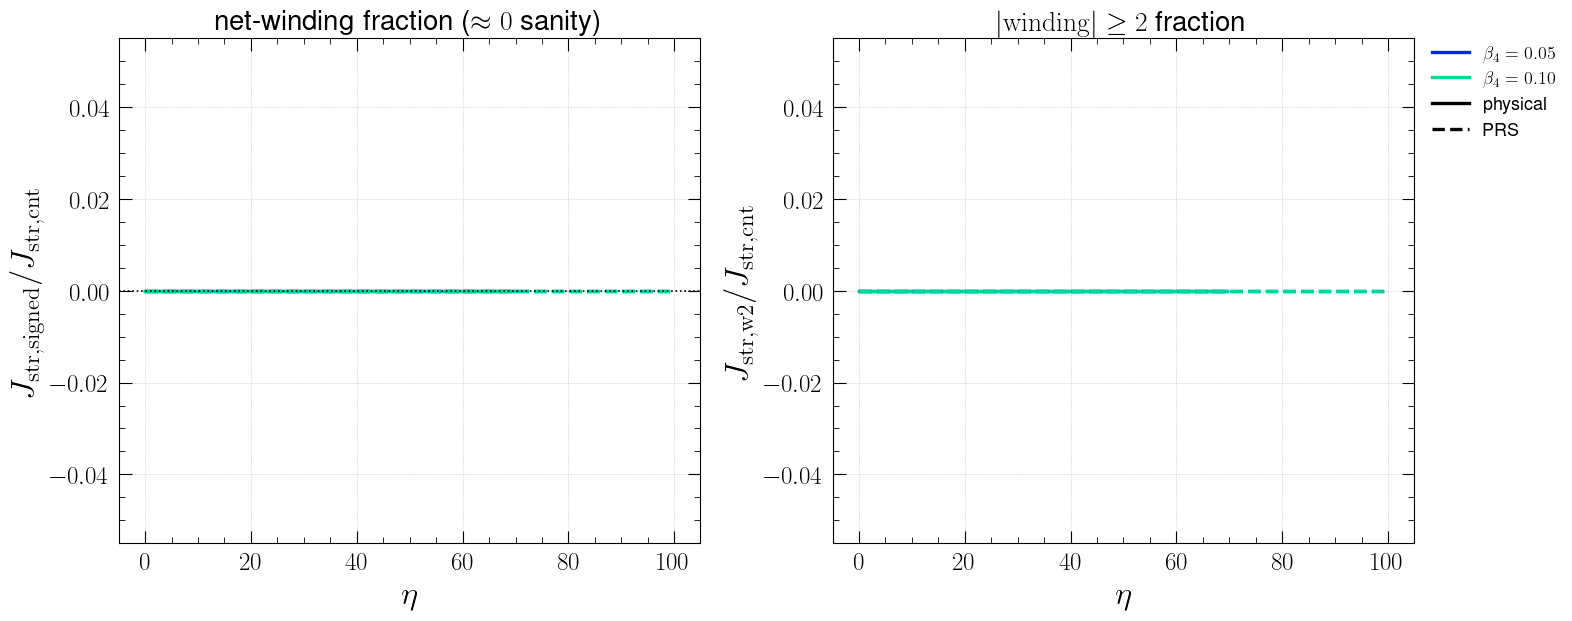

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for rid, run in RUNS_DATA.items():
    if run is None:
        continue
    color, ls = style_of(rid)
    wd = run['wall_diag']
    signed_frac = safe_ratio(wd['Jstr_signed'], wd['Jstr_cnt'])
    w2_frac = safe_ratio(wd['Jstr_w2'], wd['Jstr_cnt'])
    axes[0].plot(wd['eta'], signed_frac, color=color, ls=ls, lw=LW)
    axes[1].plot(wd['eta'], w2_frac, color=color, ls=ls, lw=LW)

axes[0].axhline(0, color='k', ls=':', lw=1.2)
paper_ax(axes[0], ylabel=r'$J_{\rm str,signed}/J_{\rm str,cnt}$',
         title=r'net-winding fraction ($\approx0$ sanity)')
paper_ax(axes[1], ylabel=r'$J_{\rm str,w2}/J_{\rm str,cnt}$',
         title=r'$|{\rm winding}|\ge2$ fraction')
make_legend(axes[1])
plt.tight_layout(); plt.show()

## A4. Resolution self-report

Left: `Jpi_edge` --- antipodal-edge resolution-flag count (rises when walls are
under-resolved). Right: `Jcore_cnt` --- count of $|\Phi|<0.3v$ core sites. Both log $y$.

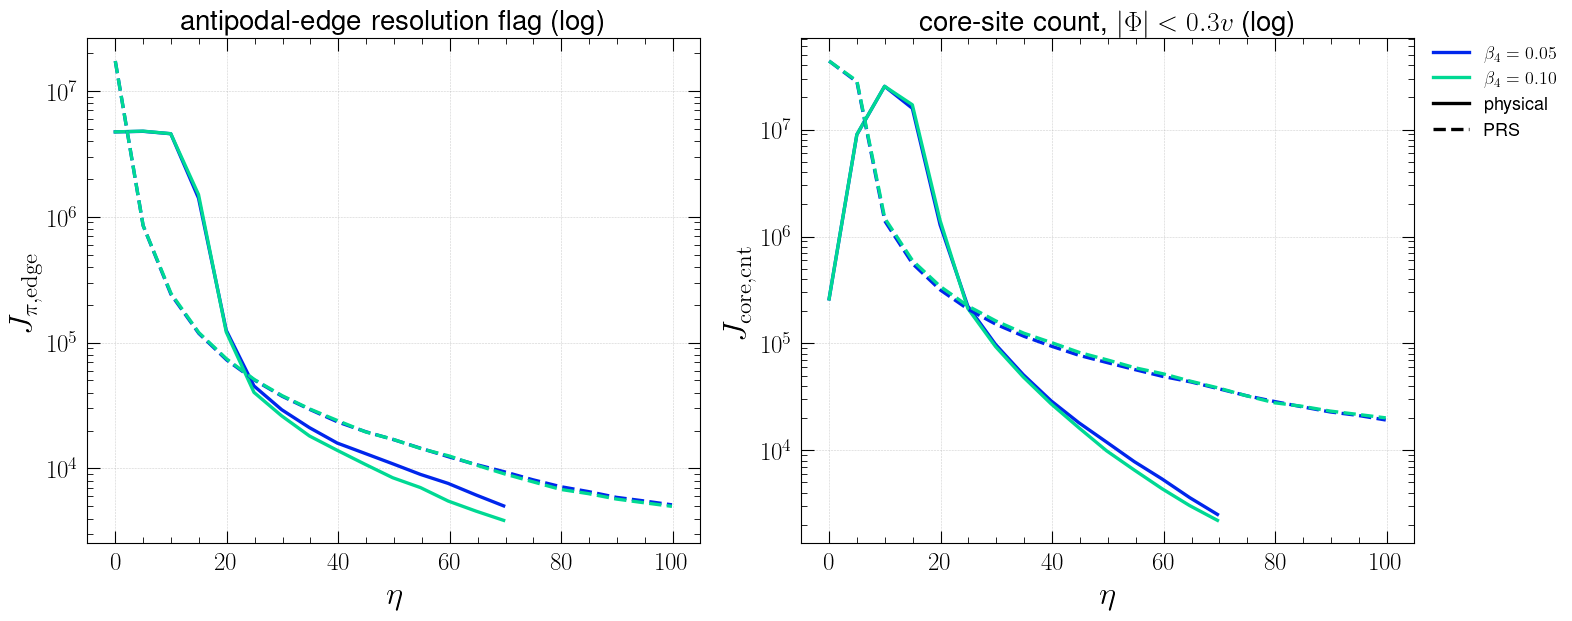

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for rid, run in RUNS_DATA.items():
    if run is None:
        continue
    color, ls = style_of(rid)
    wd = run['wall_diag']
    axes[0].plot(wd['eta'], wd['Jpi_edge'], color=color, ls=ls, lw=LW)
    axes[1].plot(wd['eta'], wd['Jcore_cnt'], color=color, ls=ls, lw=LW)

for ax in axes:
    ax.set_yscale('log')
paper_ax(axes[0], ylabel=r'$J_{\pi,{\rm edge}}$', title=r'antipodal-edge resolution flag (log)')
paper_ax(axes[1], ylabel=r'$J_{\rm core,cnt}$', title=r'core-site count, $|\Phi|<0.3v$ (log)')
make_legend(axes[1])
plt.tight_layout(); plt.show()

## A5. Junction-core resolution window (derived)

Left: junction-core lattice resolution `cells_per_core` vs scale factor $a$, with
horizontal guides at 1 and 2 cells (trustworthy region: cells $\ge1$; note this is a
*half*-width, so $1$ here $\approx$ the Z2 "$2$ cells/wall" full-width sweet spot).
Physical thins as $1/(\sqrt2\,\mu a\,DX)$; **PRS is frozen** at its $a=1$ value
($a_{\rm eff}=1$, since PRS fixes the comoving core width) so it plots as a flat line.
Right: `Jstr_len` over the resolved window (`cells_per_core >= 1`) to isolate the
trustworthy junction signal.

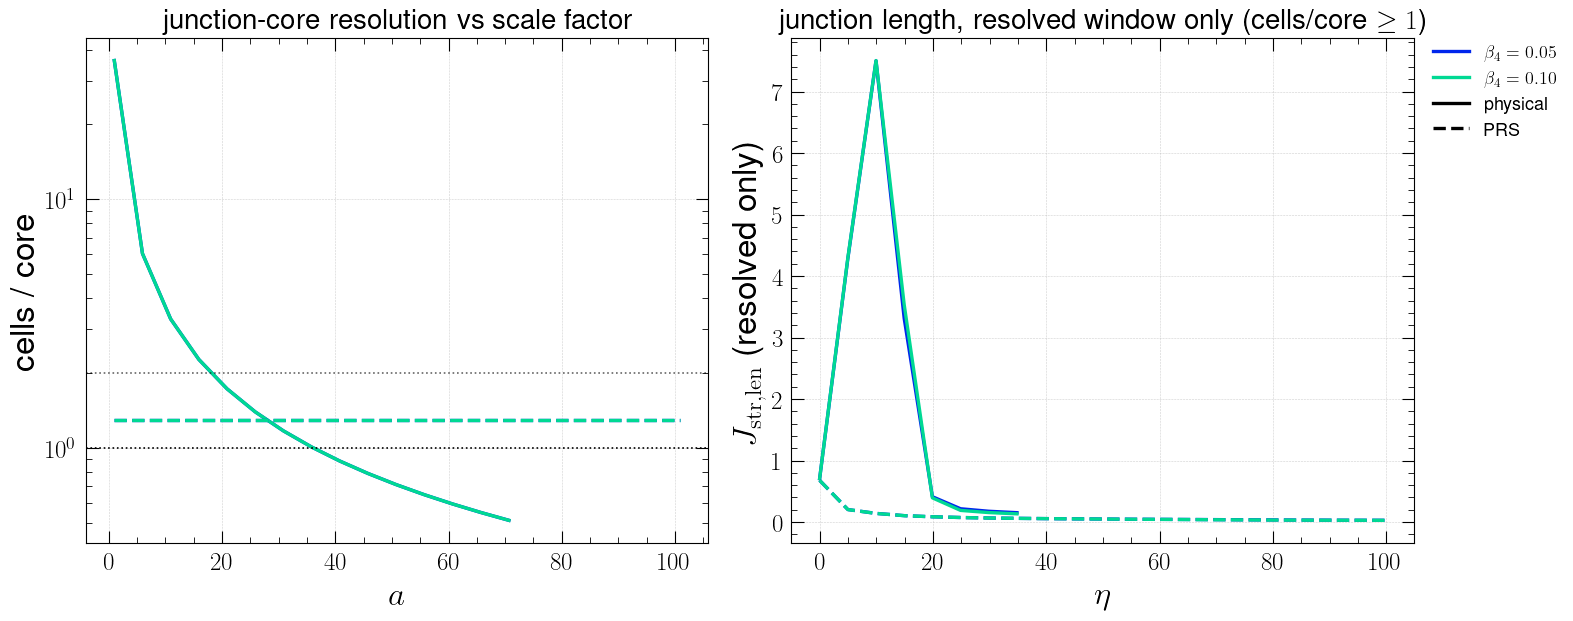

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for rid, run in RUNS_DATA.items():
    if run is None:
        continue
    color, ls = style_of(rid)
    a_arr, cpc = cells_per_core(rid, run)
    axes[0].plot(a_arr, cpc, color=color, ls=ls, lw=LW)

    wd = run['wall_diag']
    mask = cpc >= 1.0
    eta_res = np.where(mask, wd['eta'], np.nan)
    jlen_res = np.where(mask, wd['Jstr_len'], np.nan)
    axes[1].plot(eta_res, jlen_res, color=color, ls=ls, lw=LW)

axes[0].axhline(1.0, color='k', ls=':', lw=1.2)
axes[0].axhline(2.0, color='k', ls=':', lw=1.2, alpha=0.6)
axes[0].set_yscale('log')
paper_ax(axes[0], xlabel=r'$a$', ylabel=r'cells / core',
         title=r'junction-core resolution vs scale factor')
paper_ax(axes[1], ylabel=r'$J_{\rm str,len}$ (resolved only)',
         title=r'junction length, resolved window only (cells/core $\ge1$)')
make_legend(axes[1])
plt.tight_layout(); plt.show()

## A6. Velocity robustness & mask cross-check

**Left:** selector-A robustness --- the $\alpha=0.4$ $v^2\gamma^2$ line (potential cutoff
$V>\alpha V_{\rm max}$) with a band spanning $\alpha=0.2$--$0.6$, post-formation; the
narrow band shows insensitivity to the cutoff. **Right:** does the kinematic (selector-B)
site count track the geometric `scal` wall area? Ratio `velBall_N/(scal1+scal2)`, normalized
to each run's $\eta=5$ value; flat near 1 $\Rightarrow$ the mask tracks the area.

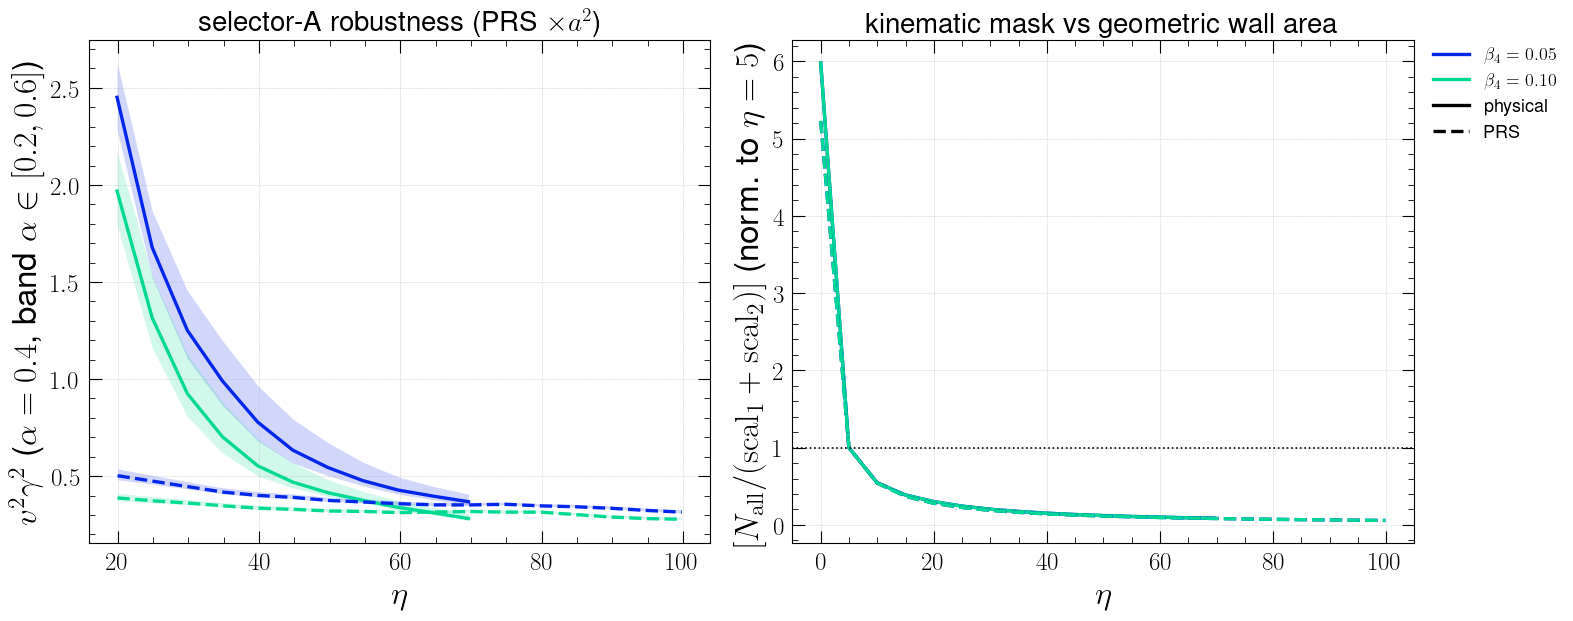

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for rid, run in RUNS_DATA.items():
    if run is None:
        continue
    color, ls = style_of(rid)
    # Left: selector-A robustness band (alpha=0.4 line, 0.2-0.6 fill), post-formation.
    eta02, vg02 = v2gamma2(run, 'velA02')
    eta04, vg04 = v2gamma2(run, 'velA04')
    eta06, vg06 = v2gamma2(run, 'velA06')
    mR = eta04 >= ETA_FORM
    axes[0].plot(eta04[mR], vg04[mR], color=color, ls=ls, lw=LW)
    lo = np.minimum(vg02, vg06)
    hi = np.maximum(vg02, vg06)
    axes[0].fill_between(eta04[mR], lo[mR], hi[mR], color=color, alpha=0.18, lw=0)

    # Right: normalized kinematic-mask vs geometric-area cross-check.
    wd = run['wall_diag']
    en = run['energies']
    scal_sum_interp = np.interp(wd['eta'], en['eta'], en['scal1'] + en['scal2'])
    mask_ratio = safe_ratio(wd['velBall_N'], scal_sum_interp)
    norm = mask_ratio[1] if (mask_ratio.size > 1 and np.isfinite(mask_ratio[1])
                             and mask_ratio[1] != 0) else np.nan
    axes[1].plot(wd['eta'], mask_ratio / norm, color=color, ls=ls, lw=LW)

axes[1].axhline(1.0, color='k', ls=':', lw=1.2)
paper_ax(axes[0], ylabel=r'$v^2\gamma^2$ ($\alpha=0.4$, band $\alpha\in[0.2,0.6]$)',
         title=r'selector-A robustness (PRS $\times a^2$)')
paper_ax(axes[1],
         ylabel=r'$[N_{\rm all}/(\mathrm{scal}_1+\mathrm{scal}_2)]$ (norm. to $\eta=5$)',
         title=r'kinematic mask vs geometric wall area')
make_legend(axes[1])
plt.tight_layout(); plt.show()

## 10. Summary table

(PRS `mean v2_*` columns carry the $\times a^2$ conformal-time normalization of §4;
physical unchanged.)

In [16]:
print(f"{'id':>10s} {'model':>9s} {'beta':>5s} {'eta_max':>8s} {'a_max':>7s} "
      f"{'a_resolved':>12s} {'Jstr_len@end_res':>17s} {'mean v2_adj':>12s} "
      f"{'mean v2_non':>12s} {'mean v2_all':>12s} {'xi_res':>9s} {'xi_slope':>9s}")
print('-' * 130)
for rid, run in RUNS_DATA.items():
    if run is None:
        print(f"{rid:>10s} NO DATA")
        continue
    r = RUNS[rid]
    wd = run['wall_diag']
    sf = run['scale_factor']
    eta_max = wd['eta'][-1]
    a_max = sf['a'][-1]

    # Junction-core resolved a-window (unchanged): still governs the junction-LENGTH
    # quantities, so Jstr_len@end_res keeps using it.
    a_arr, cpc = cells_per_core(rid, run)
    resolved = cpc >= 1.0
    if resolved.any():
        a_res_lo, a_res_hi = a_arr[resolved].min(), a_arr[resolved].max()
        a_res_str = f'{a_res_lo:.1f}-{a_res_hi:.1f}'
        last_res_idx = np.where(resolved)[0][-1]
        jstr_at_end_res = wd['Jstr_len'][last_res_idx]
    else:
        a_res_str = 'none'
        jstr_at_end_res = np.nan

    _, vg_adj = v2gamma2(run, 'velBadj')
    _, vg_non = v2gamma2(run, 'velBnon')
    _, vg_all = v2gamma2(run, 'velBall')
    v2_adj = v2_from_v2gamma2(vg_adj)
    v2_non = v2_from_v2gamma2(vg_non)
    v2_all = v2_from_v2gamma2(vg_all)

    # Velocity averages over the POST-FORMATION window eta >= ETA_FORM (NOT the junction-
    # core resolved window): the core-resolved window collapses to the eta=0 IC point for
    # the PRS runs, which would report the random IC velocity rather than the wall network.
    post_form = wd['eta'] >= ETA_FORM

    def mean_in_window(v, mask):
        vv = v[mask]
        vv = vv[np.isfinite(vv)]
        return np.mean(vv) if vv.size else np.nan

    mv_adj = mean_in_window(v2_adj, post_form)
    mv_non = mean_in_window(v2_non, post_form)
    mv_all = mean_in_window(v2_all, post_form)

    # Junction scaling parameter over the CORE-RESOLVED POST-FORMATION window
    # (eta >= ETA_FORM AND cells_per_core >= 1). For PRS this window is empty -> '--'.
    eta_xi, xi = junction_scaling(run)
    xi_win = post_form & resolved & np.isfinite(xi) & (eta_xi > 0)
    if xi_win.sum() >= 1:
        xi_res = np.mean(xi[xi_win])
        xi_res_str = f'{xi_res:9.4f}'
    else:
        xi_res_str = f"{'--':>9s}"
    if xi_win.sum() >= 2:
        coeffs = np.polyfit(np.log(eta_xi[xi_win]), np.log(xi[xi_win]), 1)
        xi_slope_str = f'{coeffs[0]:9.3f}'
    else:
        xi_slope_str = f"{'--':>9s}"

    print(f"{rid:>10s} {r['model']:>9s} {r['beta']:>5.2f} {eta_max:>8.2f} {a_max:>7.2f} "
          f"{a_res_str:>12s} {jstr_at_end_res:>17.5g} {mv_adj:>12.4f} "
          f"{mv_non:>12.4f} {mv_all:>12.4f} {xi_res_str} {xi_slope_str}")

        id     model  beta  eta_max   a_max   a_resolved  Jstr_len@end_res  mean v2_adj  mean v2_non  mean v2_all    xi_res  xi_slope
----------------------------------------------------------------------------------------------------------------------------------
 phys_b005  physical  0.05    69.65   71.50     1.0-35.8           0.15229       0.4120       0.3567       0.4119    3.1317    -0.793
 phys_b010  physical  0.10    69.65   71.50     1.0-35.8           0.13338       0.3565       0.3492       0.3565    2.8292    -0.939
  prs_b005       PRS  0.05    99.84  100.95    1.0-100.9          0.028536       0.2983       0.3380       0.2986    1.2541     0.305
  prs_b010       PRS  0.10    99.84  100.95    1.0-100.9          0.027696       0.2686       0.3351       0.2689    1.2241     0.270
